In [1]:
import numpy as np

In [2]:
!pip install -Uq pymcel

In [5]:
import pymcel as pc

In [6]:
tabla, jd, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)
X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [8]:
# Obtener la posición de Júpiter usando el mismo patrón que para el Sol
tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='Jupiter Barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)

X_jup

array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09, -1.21253772e+04,
       -4.61863891e+03,  2.90510926e+02])

In [10]:
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

r_jup_0 = X_jup[:3]
v_jup_0 = X_jup[3:]

In [11]:
deltat = 1 * 86400 # un día en segundos
r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_0, r_jup_dt

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]))

In [14]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [15]:
rij_vec_sol = r_sol_0 - r_jup_0          # vector desde Júpiter hasta el Sol
v_sol_dt = v_sol_0 - mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat

v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

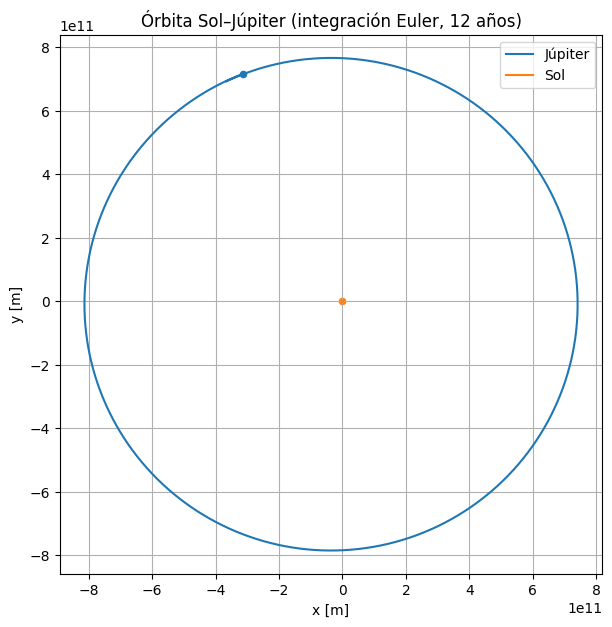

In [28]:
import matplotlib.pyplot as plt

# Tiempo total: 12 años en segundos (aprox.)
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

# Paso de integración: ya tenemos deltat = 1 día en segundos
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist = []
r_sol_hist = []
rij = r_jup - r_sol
r = np.linalg.norm(rij)
a_jup = -mu_sol * rij / r**3
a_sol =  mu_jup * rij / r**3 
v_jup = v_jup + a_jup * deltat/2  # mitad del paso para velocidad
v_sol = v_sol + a_sol * deltat/2  # mitad del paso para velocidad

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # Vector de separación Júpiter - Sol
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)

    # Aceleraciones mutuas (dos cuerpos)
    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jup * rij / r**3  # misma dirección, signo contrario y masa diferente

    # Integración tipo Euler (mismo esquema que usaste antes)
    v_jup = v_jup + a_jup * deltat  # mitad del paso para velocidad
    v_sol = v_sol + a_sol * deltat  # mitad del paso para velocidad
    r_sol = r_sol + v_sol * deltat
    r_jup = r_jup + v_jup * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jup_0[0], r_jup_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Euler, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

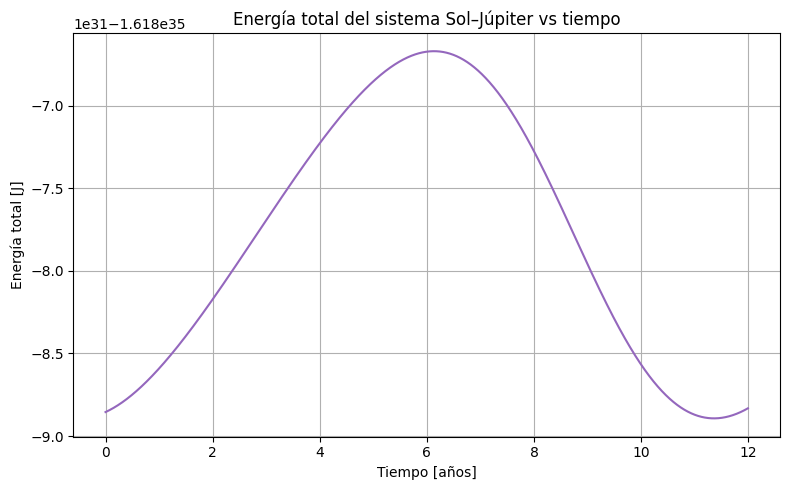

In [25]:
# Cálculo y gráfico de la energía total (cinética + potencial) en función del tiempo

# Masas a partir de parámetros gravitacionales (mu = G*M)
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_sol = mu_sol / G
M_jup = mu_jup / G

# Tiempo asociado a cada paso (en segundos y en años)
t_array = np.arange(N_steps) * deltat          # s
t_years = t_array / seconds_per_year          # años

# Posición relativa Júpiter–Sol en cada instante
r_rel = r_jup_hist - r_sol_hist               # vector r_jup - r_sol
r_norm = np.linalg.norm(r_rel, axis=1)        # distancia |r|

# Energía potencial gravitatoria (dos cuerpos)
U = -G * M_sol * M_jup / r_norm               # J

# Velocidades relativas aproximadas por diferencias finitas hacia adelante
v_jup_hist = np.diff(r_jup_hist, axis=0) / deltat
v_sol_hist = np.diff(r_sol_hist, axis=0) / deltat

# Igualamos longitud de arrays de energía recortando el último paso en U
U = U[:-1]
t_years_energy = t_years[:-1]

# Energías cinéticas
K_jup = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

E_total = K_jup + K_sol + U    # energía total

plt.figure(figsize=(8, 5))
plt.plot(t_years_energy, E_total, color="tab:purple")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía total [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()

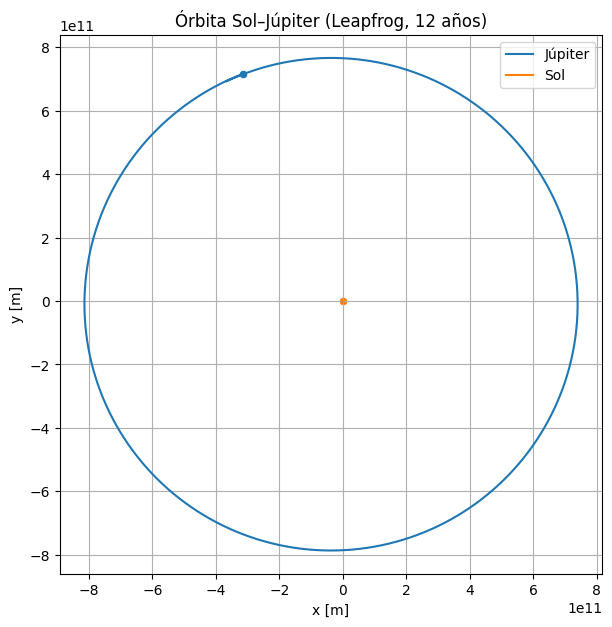

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Tiempo total: 12 años en segundos
years = 12
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year

N_steps = int(T_total // deltat)

# Inicialización
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas de trayectoria
r_jup_hist = []
r_sol_hist = []

# ---- Aceleración inicial ----
rij = r_jup - r_sol
r = np.linalg.norm(rij)

a_jup = -mu_sol * rij / r**3
a_sol =  mu_jup * rij / r**3

# ---- Kick inicial (medio paso) ----
v_jup += 0.5 * a_jup * deltat
v_sol += 0.5 * a_sol * deltat

# ===============================
#        BUCLE LEAPFROG
# ===============================

for _ in range(N_steps):

    # ---- Drift (paso completo en posición) ----
    r_jup += v_jup * deltat
    r_sol += v_sol * deltat

    # Guardamos posiciones
    r_jup_hist.append(r_jup.copy())
    r_sol_hist.append(r_sol.copy())

    # ---- Nuevas aceleraciones ----
    rij = r_jup - r_sol
    r = np.linalg.norm(rij)

    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jup * rij / r**3

    # ---- Kick (medio paso final) ----
    v_jup += a_jup * deltat
    v_sol += a_sol * deltat


r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# ===============================
#           GRÁFICA
# ===============================

plt.figure(figsize=(7, 7))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol")

plt.scatter(r_jup_0[0], r_jup_0[1], s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (Leapfrog, 12 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

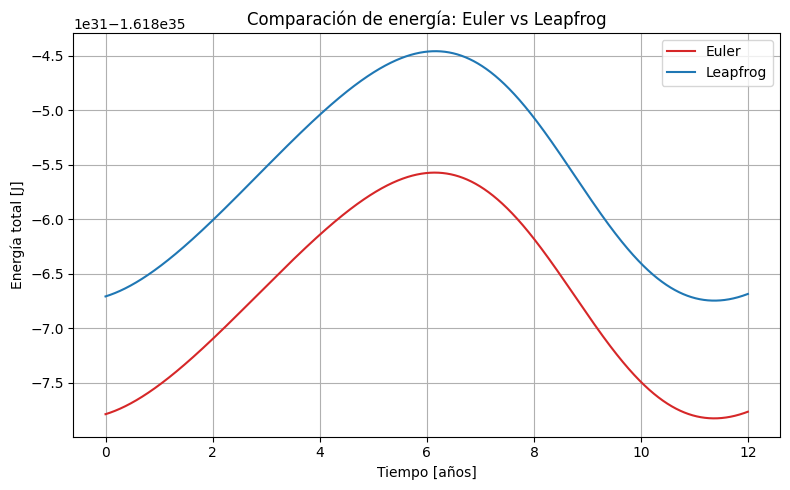

In [31]:
# ==============================

# COMPARACIÓN DE ENERGÍA: EULER vs LEAPFROG

# ==============================



import numpy as np

import matplotlib.pyplot as plt



G = 6.67430e-11



M_sol = mu_sol / G

M_jup = mu_jup / G



# ==============================

# 1) ENERGÍA CON EULER

#    (usa r_jup_hist_e, r_sol_hist_e)

# ==============================



# Tiempo

t_array_e = np.arange(len(r_jup_hist_e)) * deltat

t_years_e = t_array_e / seconds_per_year



# Distancia relativa

r_rel_e = r_jup_hist_e - r_sol_hist_e

r_norm_e = np.linalg.norm(r_rel_e, axis=1)



# Energía potencial

U_e = -G * M_sol * M_jup / r_norm_e



# Velocidades por diferencias finitas

v_jup_hist_e = np.diff(r_jup_hist_e, axis=0) / deltat

v_sol_hist_e = np.diff(r_sol_hist_e, axis=0) / deltat



# Igualamos longitudes recortando el último punto en potencial y tiempo

U_e = U_e[:-1]

t_years_e = t_years_e[:-1]



K_jup_e = 0.5 * M_jup * np.sum(v_jup_hist_e**2, axis=1)

K_sol_e = 0.5 * M_sol * np.sum(v_sol_hist_e**2, axis=1)



E_total_e = K_jup_e + K_sol_e + U_e



# ==============================

# 2) ENERGÍA CON LEAPFROG

#    (usa r_jup_hist_l, r_sol_hist_l)

# ==============================



# Tiempo

t_array_l = np.arange(len(r_jup_hist_l)) * deltat

t_years_l = t_array_l / seconds_per_year



# Distancia relativa

r_rel_l = r_jup_hist_l - r_sol_hist_l

r_norm_l = np.linalg.norm(r_rel_l, axis=1)



# Energía potencial

U_l = -G * M_sol * M_jup / r_norm_l



# Velocidades por diferencias finitas

v_jup_hist_l = np.diff(r_jup_hist_l, axis=0) / deltat

v_sol_hist_l = np.diff(r_sol_hist_l, axis=0) / deltat



# Igualamos longitudes

U_l = U_l[:-1]

t_years_l = t_years_l[:-1]



K_jup_l = 0.5 * M_jup * np.sum(v_jup_hist_l**2, axis=1)

K_sol_l = 0.5 * M_sol * np.sum(v_sol_hist_l**2, axis=1)



E_total_l = K_jup_l + K_sol_l + U_l



# ==============================

# 3) GRÁFICA COMPARATIVA

# ==============================



plt.figure(figsize=(8,5))

plt.plot(t_years_e, E_total_e, label="Euler", color="tab:red")

plt.plot(t_years_l, E_total_l, label="Leapfrog", color="tab:blue")

plt.xlabel("Tiempo [años]")

plt.ylabel("Energía total [J]")

plt.title("Comparación de energía: Euler vs Leapfrog")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()